In [1]:
from scipy import stats
from statsmodels.stats.weightstats import ztest
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import numpy as np
import statistics as st
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
import random

data = pd.read_csv('nba_second_round_history.csv')
ts = pd.read_csv('nba_true_shooting_data.csv')
# hide 2026 season data since it's not complete and may skew the analysis
data = data[data['Season'] < 2026]
ts = ts[ts['Season'] < 2026]
# detect missing values
print(data.isnull().sum())
print(ts.isnull().sum())
data

Season                    0
Team                      0
Opponent                  0
Games played              0
Average Points scored     0
Average Points allowed    0
Offensive Rating          0
Defensive Rating          0
eFG%                      0
Opp eFG%                  0
TOV%                      0
Opp TOV%                  0
ORB%                      0
Opp ORB%                  0
FT/FGA                    0
Opp FT/FGA                0
Champion                  0
dtype: int64
Season      0
Team        0
Opponent    0
Team PTS    0
Team FGA    0
Team FTA    0
Team TS%    0
Opp PTS     0
Opp FGA     0
Opp FTA     0
Opp TS%     0
dtype: int64


,Season,Team,Opponent,Games played,Average Points scored,Average Points allowed,Offensive Rating,Defensive Rating,eFG%,Opp eFG%,TOV%,Opp TOV%,ORB%,Opp ORB%,FT/FGA,Opp FT/FGA,Champion
0,1984,BOS,NYK,7,111.0,103.0,113.9,105.7,0.498,0.484,14.2,16.0,38.7,35.0,0.285,0.296,True
1,1984,MIL,NJN,6,98.2,96.3,102.8,100.9,0.471,0.405,18.3,12.2,32.6,35.5,0.373,0.340,False
2,1984,LAL,DAL,5,120.6,106.2,121.9,107.4,0.570,0.454,12.8,11.9,37.8,35.1,0.200,0.232,False
3,1984,PHO,UTA,6,103.7,101.0,107.0,104.3,0.462,0.468,12.9,15.3,33.9,32.4,0.230,0.300,False
4,1985,BOS,DET,6,120.5,112.7,118.1,110.4,0.519,0.478,13.6,11.4,37.1,35.7,0.302,0.196,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,2024,MIN,DEN,7,102.7,97.6,113.8,108.1,0.539,0.517,11.5,12.4,22.8,21.1,0.201,0.173,False
164,2025,IND,CLE,5,117.6,114.2,116.7,113.3,0.585,0.490,13.3,11.7,18.0,28.8,0.220,0.295,False
165,2025,NYK,BOS,6,105.7,105.2,112.9,112.4,0.508,0.515,11.7,12.2,29.6,27.6,0.211,0.176,False
166,2025,OKC,DEN,7,115.4,106.3,114.6,105.6,0.518,0.481,9.7,15.1,24.9,28.0,0.208,0.249,True


Data Augmentation

In [11]:
# 1. Add Net Rating column (淨效率值 = 每100回合的得分 - 每100回合的失分) (better measure of team performance than point differential because it accounts for pace)
data['Net Rating'] = (data['Offensive Rating'] - data['Defensive Rating']).round(3)

# 2. Add Average Points Difference column
data['Average Points Difference'] = (data['Average Points scored'] - data['Average Points allowed']).round(3)

# 3. Add eFG% Difference column (eFG% 有效命中率 = 總命中數＋0.5*三分球的命中數）/ 總出手數)
data['eFG% Difference'] = ((data['eFG%'] - data['Opp eFG%']) * 100).round(3)

# 4. Add TOV% Difference column (TOV% 失誤率 = 失誤數 / 總出手數)
data['TOV% Difference'] = ((data['TOV%'] - data['Opp TOV%'])).round(3)

# 5. Add ORB% Difference column
data['ORB% Difference'] = (data['ORB%'] - data['Opp ORB%']).round(3)

# 6. Add FT/FGA Difference column
data['FT/FGA Difference'] = (data['FT/FGA'] - data['Opp FT/FGA']).round(3)

# 7. Add Actual Wins column
data['Actual Wins (%)'] = (4 / data['Games played'] * 100).round(3)

# 8. Add Pythagorean Wins column (a measure of dominance)(https://gemini.google.com/share/081f957375cf)
data['Pythagorean Wins (13.91) (%)'] = ((data['Average Points scored'] ** 13.91) / ((data['Average Points scored'] ** 13.91) + (data['Average Points allowed'] ** 13.91)) * 100).round(3)
data['Pythagorean Wins (16.5) (%)'] = ((data['Average Points scored'] ** 16.5) / ((data['Average Points scored'] ** 16.5) + (data['Average Points allowed'] ** 16.5)) * 100).round(3)

# 9. Add True Shooting Percentage Difference column (TS% 真實命中率 = 總得分 / (2 * (總出手數 + 0.44 * 罰球數)))
data['TS% Difference'] = ((ts['Team TS%'] - ts['Opp TS%'])).round(3)

# Save the modified dataset to a new CSV file
data.to_csv('nba_second_round_history_modified.csv', index=False)

History Line Plots

<Axes: xlabel='Season', ylabel='Net Rating'>

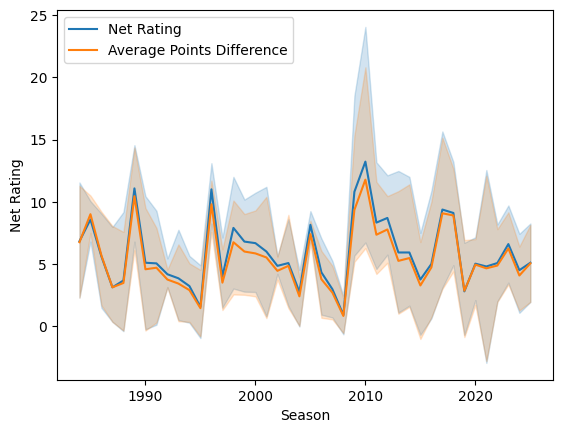

In [13]:
sns.lineplot(data=data, x='Season', y='Net Rating', label='Net Rating')
sns.lineplot(data=data, x='Season', y='Average Points Difference', label='Average Points Difference')

<Axes: xlabel='Season', ylabel='eFG% Difference'>

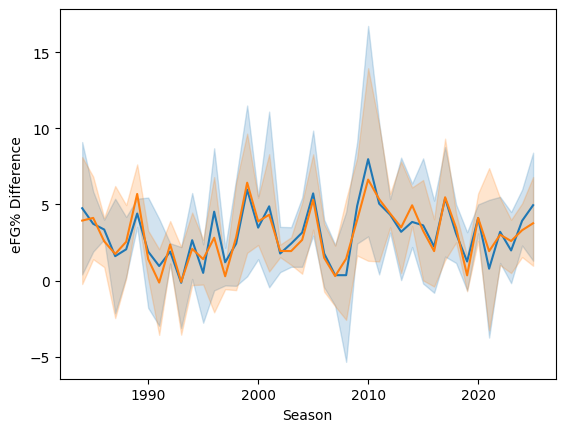

In [ ]:
sns.lineplot(data=data, x='Season', y='eFG% Difference', label='eFG% Difference')
sns.lineplot(data=data, x='Season', y='TS% Difference', label='TS% Difference')

<Axes: xlabel='Season', ylabel='Pythagorean Wins (13.91) (%)'>

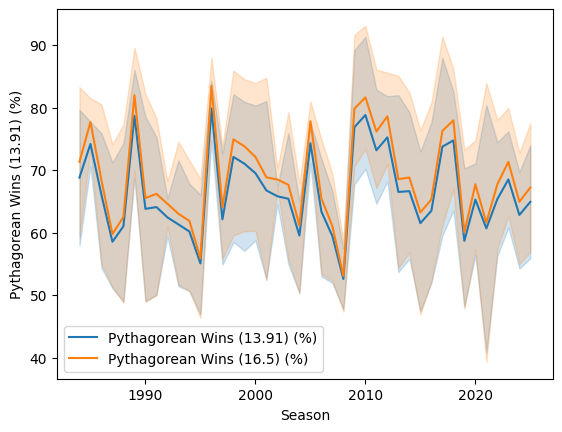

In [14]:
sns.lineplot(data=data, x='Season', y='Pythagorean Wins (13.91) (%)', label='Pythagorean Wins (13.91) (%)')
sns.lineplot(data=data, x='Season', y='Pythagorean Wins (16.5) (%)', label='Pythagorean Wins (16.5) (%)')

Pythagorean Wins Statistics & Plot

In [58]:
print(data['Pythagorean Wins (13.91) (%)'].describe())
print('\n')
print(data['Pythagorean Wins (16.5) (%)'].describe())

count    168.000000
mean      66.490607
std       12.656688
min       40.106000
25%       56.366250
50%       66.431500
75%       75.977500
max       97.681000
Name: Pythagorean Wins (13.91) (%), dtype: float64


count    168.000000
mean      68.746798
std       14.052259
min       38.327000
25%       57.534750
50%       69.204000
75%       79.670750
max       98.831000
Name: Pythagorean Wins (16.5) (%), dtype: float64


<Axes: xlabel='Pythagorean Wins (13.91) (%)', ylabel='Count'>

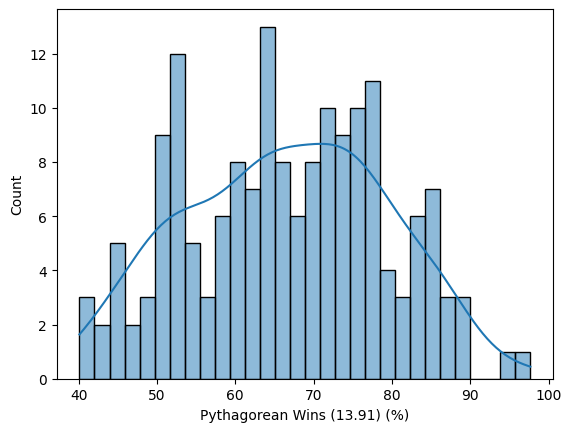

In [59]:
sns.histplot(data['Pythagorean Wins (13.91) (%)'], bins=30, kde=True)

<Axes: xlabel='Pythagorean Wins (16.5) (%)', ylabel='Count'>

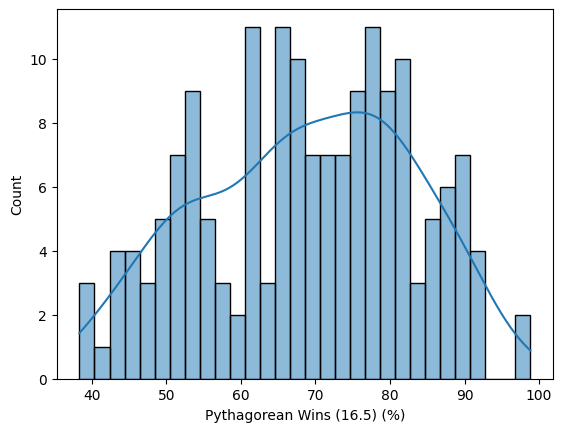

In [60]:
sns.histplot(data['Pythagorean Wins (16.5) (%)'], bins=30, kde=True)

Relation between two metrics

<Axes: xlabel='Games played', ylabel='Pythagorean Wins (13.91) (%)'>

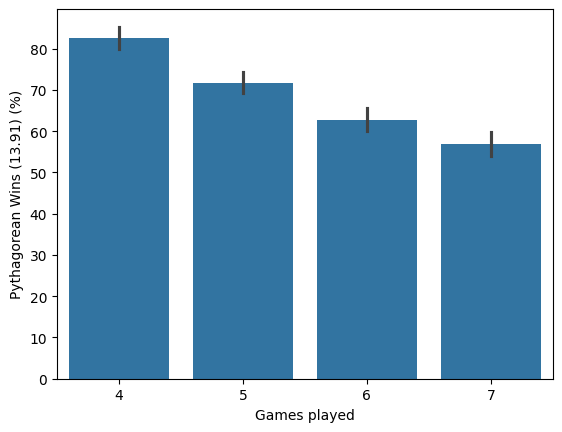

In [61]:
sns.barplot(data=data, x='Games played', y='Pythagorean Wins (13.91) (%)')

<Axes: xlabel='Games played', ylabel='Pythagorean Wins (16.5) (%)'>

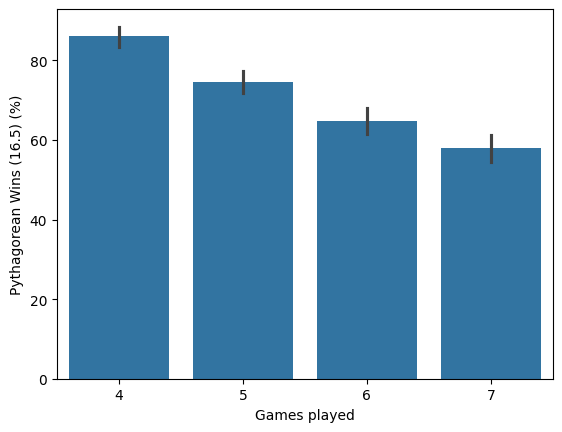

In [62]:
sns.barplot(data=data, x='Games played', y='Pythagorean Wins (16.5) (%)')

<Axes: xlabel='Games played', ylabel='Pythagorean Wins (13.91) (%)'>

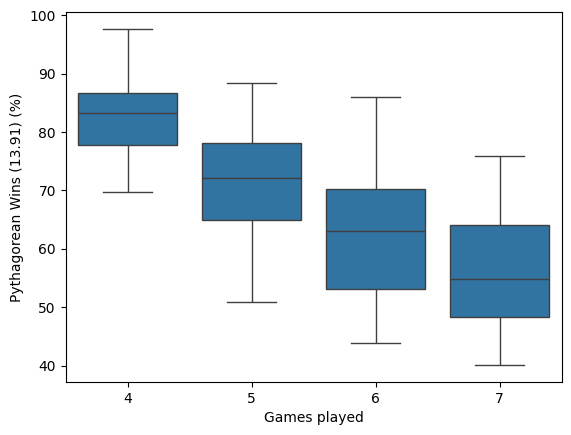

In [63]:
sns.boxplot(data=data, y='Pythagorean Wins (13.91) (%)', x='Games played')

Games Played Plot

   Games played  Count
0             7     46
1             6     48
2             5     52
3             4     22


<Axes: xlabel='Games played', ylabel='Count'>

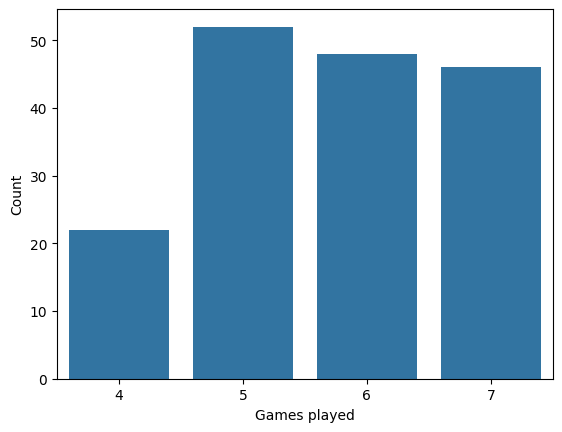

In [64]:
games_played = data['Games played'].value_counts(sort=False).reset_index(name='Count')
print(games_played)
sns.barplot(data=games_played, x='Games played', y='Count')

Dominant Statistics (Grouped by Games Played)

In [ ]:
dominant = data[data['Games played'] <= 5]
non_dominant = data[data['Games played'] > 5]

Champions Statistics

In [65]:
champs = data[data['Champion'] == 1]
non_champs = data[data['Champion'] == 0]

1. Net Rating (淨效率值)

<Axes: xlabel='Champion', ylabel='Net Rating'>

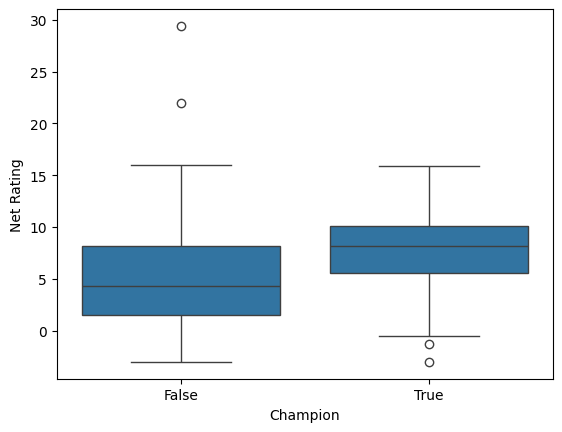

In [66]:
sns.boxplot(data=data, y='Net Rating', x='Champion')

Net Rating Difference between Champions and Non-Champions:
count    42.000000
mean      2.579365
std       4.575413
min      -8.242063
25%       0.357937
50%       2.907937
75%       4.907937
max      10.657937
Name: Net Rating, dtype: float64


<Axes: xlabel='Net Rating', ylabel='Count'>

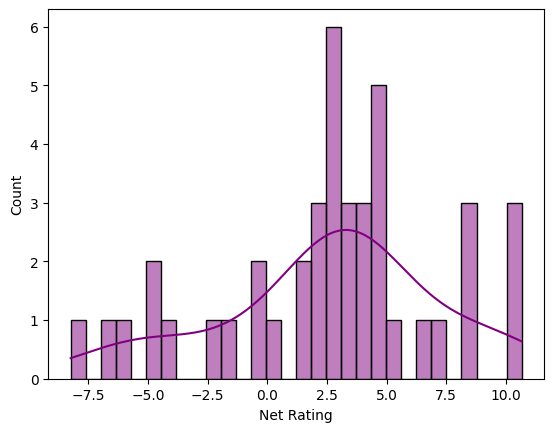

In [67]:
netrtg_diff = champs['Net Rating'] - non_champs['Net Rating'].mean()
print('Net Rating Difference between Champions and Non-Champions:')
print(netrtg_diff.describe())

sns.histplot(netrtg_diff, bins=30, kde=True, color='purple', label='Champions vs Non-Champions')

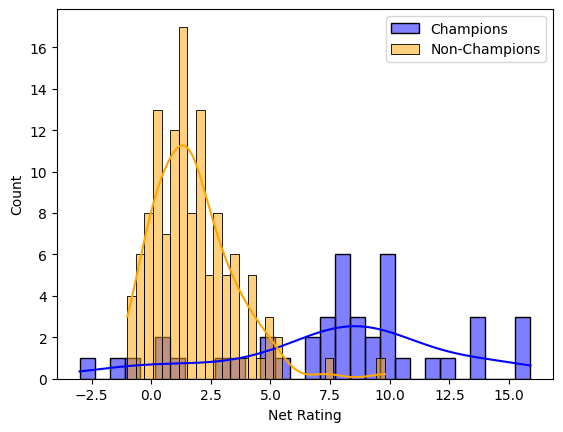

In [68]:
sns.histplot(champs['Net Rating'], bins=30, kde=True, color='blue', label='Champions')
sns.histplot(non_champs['Net Rating'] / 3, bins=30, kde=True, color='orange', label='Non-Champions')
plt.legend()

Effective Field Goal % (有效命中率)

<Axes: xlabel='Champion', ylabel='eFG% Difference'>

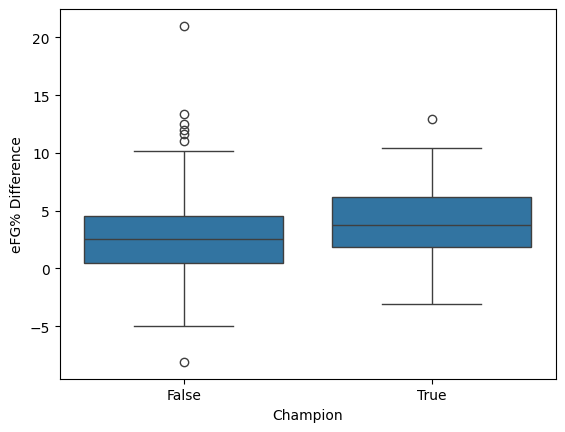

In [69]:
sns.boxplot(data=data, y='eFG% Difference', x='Champion')

eFG% Difference between Champions and Non-Champions:
count    42.000000
mean      1.125397
std       3.362712
min      -5.900794
25%      -0.950794
50%       0.949206
75%       3.374206
max      10.099206
Name: eFG% Difference, dtype: float64


<Axes: xlabel='eFG% Difference', ylabel='Count'>

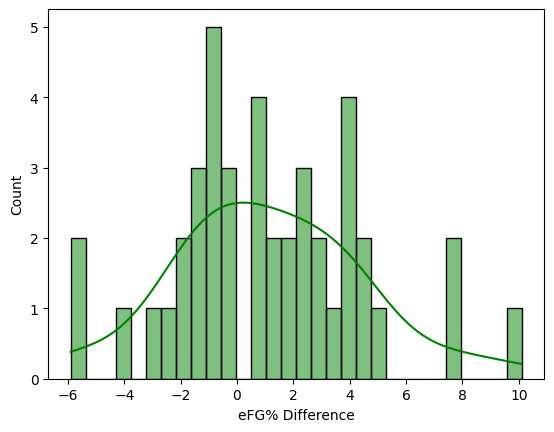

In [70]:
efg_diff = champs['eFG% Difference'] - non_champs['eFG% Difference'].mean()
print('eFG% Difference between Champions and Non-Champions:')
print(efg_diff.describe())

sns.histplot(efg_diff, bins=30, kde=True, color='green', label='Champions vs Non-Champions')

Difference between eFG% too small (?)

3. Turn Over % (失誤率)